# Feature Space Analysis: SST vs Chlorophyll-a

This notebook explores the relationship between Sea Surface Temperature (SST) and Chlorophyll-a concentration, colored by month to reveal seasonal patterns.

In [5]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from matplotlib.colors import Normalize

## Load the Pickle Dataset

In [6]:
# Load the pickle file
with open(r'E:\satdata\Custom\combined_sst_chlor_cdom_2005-2011.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print(f"Dataset loaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded successfully!
Date range: 2005-01-01 00:00:00 to 2011-12-31 00:00:00
Total records: 2562
Columns: ['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom', 'cdom_n_points']


## Extract and Flatten Data for Scatter Plot

In [9]:
# Extract all data points from the gridded dataset
sst_values = []
chlor_values = []
month_values = []

for date_idx, row in df.iterrows():
    # Extract month from the date index (1-12)
    month = date_idx.month
    
    # Get SST and chlorophyll grids
    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    
    # Skip if either grid is None or NaN
    if sst_grid is None or chlor_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    
    # Convert to numpy arrays
    sst_array = np.array(sst_grid)
    chlor_array = np.array(chlor_grid)
    
    # Flatten the grids
    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    
    # Create mask for valid data (both SST and Chlor must be valid)
    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat)
    
    # Append valid data points
    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    month_values.extend([month] * np.sum(valid_mask))

# Convert to numpy arrays
sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
month_values = np.array(month_values)

print(f"Total valid data points before subsampling: {len(sst_values):,}")

# Subsample to 500K points if we have more than that
max_points = 50000
if len(sst_values) > max_points:
    # Generate random indices
    np.random.seed(42)  # For reproducibility
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    
    # Subsample all arrays
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    month_values = month_values[random_indices]
    
    print(f"Subsampled to {max_points:,} points")
else:
    print(f"Using all {len(sst_values):,} points (less than {max_points:,})")

print(f"SST range: {np.min(sst_values):.2f} to {np.max(sst_values):.2f} °C")
print(f"Chlorophyll range: {np.min(chlor_values):.4f} to {np.max(chlor_values):.4f} mg/m³")
print(f"Months represented: {sorted(np.unique(month_values))}")

Total valid data points before subsampling: 33,142,305
Subsampled to 50,000 points
SST range: 7.93 to 32.81 °C
Chlorophyll range: 0.0145 to 85.4360 mg/m³
Months represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


## Create Scatter Plot: SST vs Chlorophyll-a (Colored by Month)

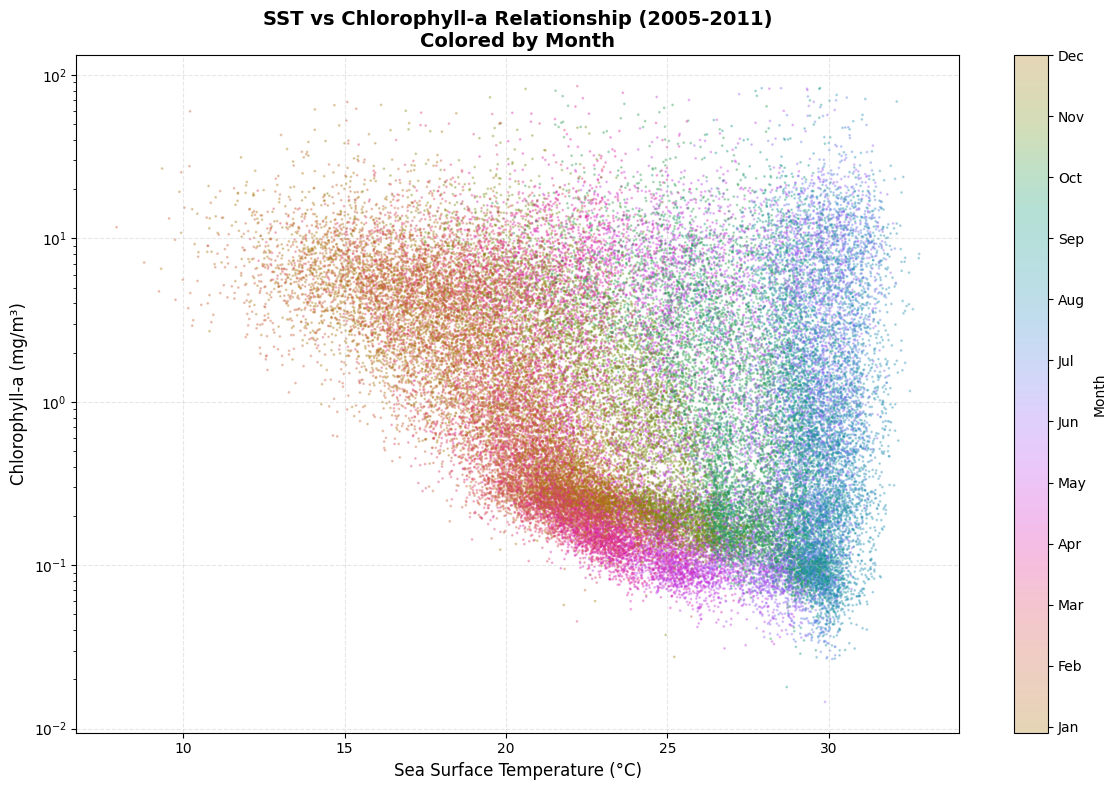

Scatter plot created with 50,000 data points


In [10]:
# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with month as color
# Use cmocean.cm.phase for cyclic month coloring (reversed)
scatter = ax.scatter(
    sst_values, 
    chlor_values,
    c=month_values,
    cmap=cmocean.cm.phase,
    s=1,  # Small point size for large dataset
    alpha=0.3,  # Transparency to show density
    vmin=12,  # Flipped: December at bottom
    vmax=1,   # January at top
    rasterized=True  # Rasterize for better performance with many points
)

# Set y-axis to log scale (typical for chlorophyll)
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Sea Surface Temperature (°C)', fontsize=12)
ax.set_ylabel('Chlorophyll-a (mg/m³)', fontsize=12)
ax.set_title('SST vs Chlorophyll-a Relationship (2005-2011)\nColored by Month', 
             fontsize=14, fontweight='bold')

# Add colorbar with month labels (reversed order)
cbar = plt.colorbar(scatter, ax=ax, label='Month', ticks=np.arange(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Tight layout
plt.tight_layout()
plt.show()

print(f"Scatter plot created with {len(sst_values):,} data points")

## 3D Scatter Plot: SST vs Chlorophyll-a vs Month

C:\Users\Makai\AppData\Local\Temp\ipykernel_37616\3864090721.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


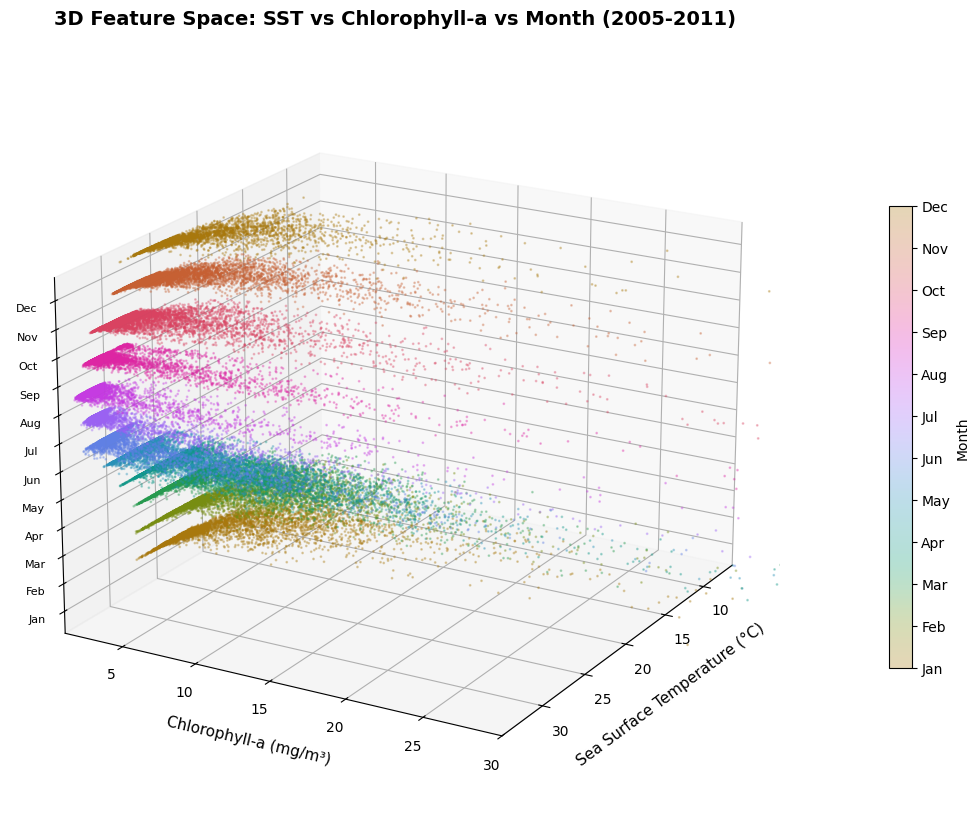

3D scatter plot created with 50,000 data points


In [19]:
# Create 3D scatter plot with month as Z-axis
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot
scatter = ax.scatter(
    sst_values, 
    chlor_values,
    month_values,  # Z-axis is month
    c=month_values,  # Color also by month
    cmap=cmocean.cm.phase_r,  # Reversed colormap for flipped appearance
    s=1,  # Small point size
    alpha=0.3,
    vmin=1,  # January
    vmax=12,  # December
    rasterized=True
)

# Labels
ax.set_xlabel('Sea Surface Temperature (°C)', fontsize=11, labelpad=10)
ax.set_ylabel('Chlorophyll-a (mg/m³)', fontsize=11, labelpad=10)
ax.set_zlabel('Month', fontsize=11, labelpad=10)
ax.set_title('3D Feature Space: SST vs Chlorophyll-a vs Month (2005-2011)', 
             fontsize=14, fontweight='bold', pad=20)

# Set Z-axis ticks to show month names
ax.set_zticks(np.arange(1, 13))
ax.set_zticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=8)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Month', shrink=0.6, pad=0.1, 
                     ticks=np.arange(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Set viewing angle for better perspective
ax.view_init(elev=20, azim=30)

ax.set_ylim3d(1, 30)  # Set y-axis limits for better view

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"3D scatter plot created with {len(sst_values):,} data points")